# H.E.A.R.T
## Helping Every At-Risk Mother Thrive

Import neccesary libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Load Dataset

In [6]:
df = pd.read_csv('/Users/gracysutaria/Documents/UCI/VenusHacks/H.E.A.R.T-/Maternal_health.csv')

In [7]:
df.shape

(1205, 12)

In [8]:
df.head()

,Age,Systolic BP,Diastolic,BS,Body Temp,BMI,Previous Complications,Preexisting Diabetes,Gestational Diabetes,Mental Health,Heart Rate,Risk Level
0,22,90.0,60.0,9.0,100,18.0,1.0,1.0,0,1,80.0,High
1,22,110.0,70.0,7.1,98,20.4,0.0,0.0,0,0,74.0,Low
2,27,110.0,70.0,7.5,98,23.0,1.0,0.0,0,0,72.0,Low
3,20,100.0,70.0,7.2,98,21.2,0.0,0.0,0,0,74.0,Low
4,20,90.0,60.0,7.5,98,19.7,0.0,0.0,0,0,74.0,Low


## Clean/Impute Data

In [9]:
df = df.dropna(subset=['Risk Level'])
df.shape

(1187, 12)

In [10]:
df['Risk Level'] = df['Risk Level'].str.strip().str.lower()

In [11]:
df.isna().sum()

Age                        0
Systolic BP                4
Diastolic                  2
BS                         1
Body Temp                  0
BMI                       14
Previous Complications     1
Preexisting Diabetes       1
Gestational Diabetes       0
Mental Health              0
Heart Rate                 1
Risk Level                 0
dtype: int64

In [12]:
continuous_cols = ['Age', 'Systolic BP', 'Diastolic', 'BS', 'BMI', 'Heart Rate']
for col in continuous_cols + ['Body Temp']:
        df[col] = df[col].fillna(df[col].median())


In [13]:
binary_cols = ['Previous Complications', 'Preexisting Diabetes']
for col in binary_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Outliers

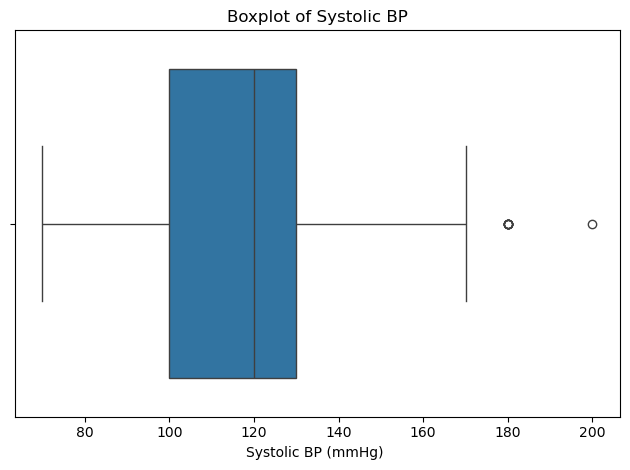

In [15]:
sns.boxplot(x=df['Systolic BP'])
plt.title("Boxplot of Systolic BP")
plt.xlabel("Systolic BP (mmHg) ")
plt.tight_layout()
plt.show()